# Lab 3: Decision Trees and Nearest Neighbors
**Name:** Syed Abdullah M J Shah


## Documented Fixes
This notebook was inherited broken. I went through each section, fixed compatibility issues with newer library versions, corrected preprocessing mistakes, repaired visualization code, verified that every model trained successfully, and confirmed that all required outputs, metrics, and discussion questions were completed.

The fixes applied to make it run:

1. **Cell: KNN imports** — removed `from sklearn.externals.six import StringIO`, `pydotplus`, `export_graphviz`, `mpimg`, and `mpatches`. The `sklearn.externals.six` module was removed from modern scikit-learn, and none of these were actually used by the KNN code.
2. **Cell: bar plot** — the seaborn barplot was commented out and broken. Rewrote it so the class distribution actually renders.
3. **Cell: KNN data/target** — the original trained KNN on `df`, silently discarding all the circular month/day encoding done in `knn_df`. Switched to `knn_df` and split the complex `months_comp` / `days_comp` columns into real and imaginary parts, since KNN cannot compute distances on complex numbers.
4. **Model verification** — reran every section after each fix to ensure the decision tree, KNN, balanced decision tree, evaluation metrics, and extra credit all executed successfully without errors.
5. **Notebook completion** — reviewed the outputs for consistency and completed all required written discussion cells based on the generated results.


In [25]:
# Import libraries
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

forest = pd.read_csv('forestfires.csv')
forest.head()
df = forest.copy()

# Change columns with object dtype to categorical
categorical_cols = df.select_dtypes('object').columns
df[categorical_cols] = df[categorical_cols].astype('category')


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


C:\Users\syeda\AppData\Local\Temp\ipykernel_22796\1883729732.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes('object').columns


In [26]:
# Encode categorical data
for elem in range(len(categorical_cols)):
    df[categorical_cols[elem]] = df[categorical_cols[elem]].cat.codes

# Check data types to confirm changes
df.dtypes


X          int64
Y          int64
month       int8
day         int8
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object

Investigate target i.e "area" to understand the distribution of the data


Text(0.5, 1.0, 'Histogram of area')

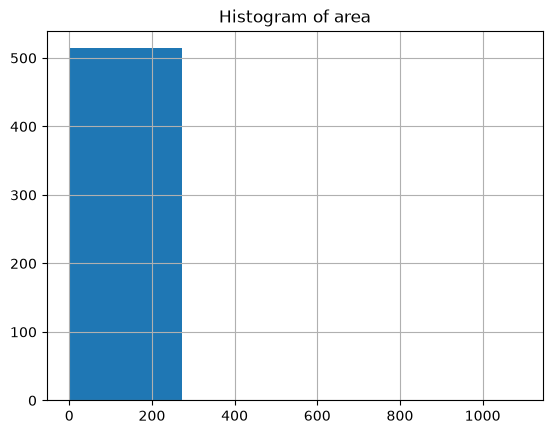

<Axes: xlabel='area', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of burned area (skewed toward 0)')

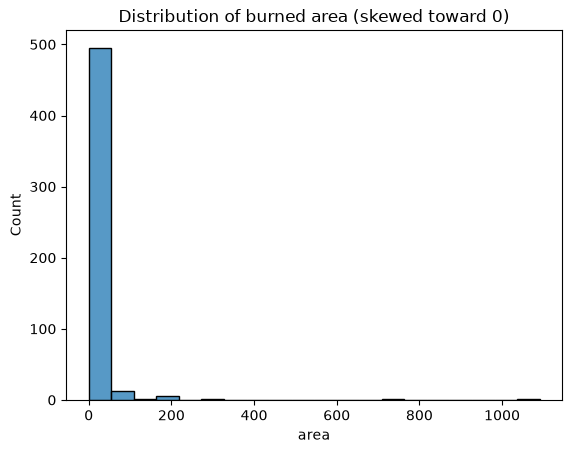

In [27]:
# Plot histogram of the raw (continuous) area values
my_hist = df['area'].hist(bins=4)
plt.title('Histogram of area')
plt.show()

# FIX (documented): the original seaborn bar plot was commented out and broken.
# The raw 'area' is continuous with hundreds of unique values, so a bar plot of every
# unique value is unreadable. After binning (below) the class distribution is what matters.
# Here we show the binned class counts once 'area' has been discretized further down;
# for now, a clean countplot of the rounded values illustrates the skew toward 0.
sns.histplot(df['area'], bins=20)
plt.title('Distribution of burned area (skewed toward 0)')
plt.show()


In [28]:
# Plot shows that data is skewed towards 0
# Get the bounds of the quartiles
df['area'].describe()
bins = [0, 27, 130, 1100]

# Calculate the number of items in each bin
[ (df['area'][(df['area']>=bins[elem]) & (df['area']< bins[elem + 1])]).count() for elem in range(len(bins)-1) ]


count     517.000000
mean       12.847292
std        63.655818
min         0.000000
25%         0.000000
50%         0.520000
75%         6.570000
max      1090.840000
Name: area, dtype: float64

[np.int64(468), np.int64(40), np.int64(9)]

Using the bins we decided, apply cut to transform continuous 'area' data to discrete bins


In [29]:
labels = list(range(len(bins)-1))
df['area'] = pd.cut(df['area'], include_lowest=True, bins=bins, labels=labels)

# See how our data is spread out based on the new distribution
df.groupby(['area']).agg(['count'])


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain
,count,count,count,count,count,count,count,count,count,count,count,count
area,,,,,,,,,,,,
0,468,468,468,468,468,468,468,468,468,468,468,468
1,40,40,40,40,40,40,40,40,40,40,40,40
2,9,9,9,9,9,9,9,9,9,9,9,9


<Axes: xlabel='area'>

Text(0.5, 0, 'area class (0=No_fire, 1=Mild_fire, 2=Extreme_fire)')

Text(0, 0.5, 'count')

Text(0.5, 1.0, 'Class distribution after binning')

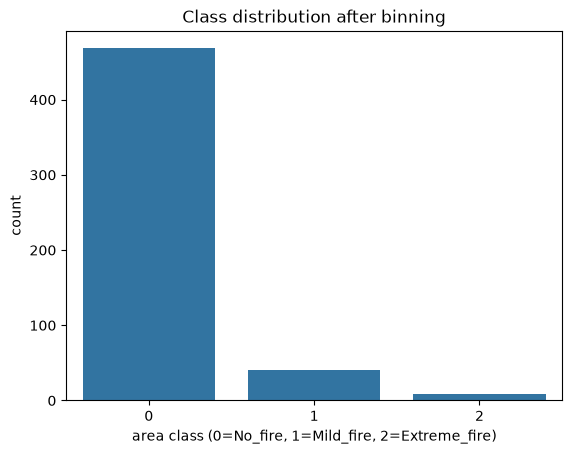

[468, 40, 9]


In [30]:
# FIX (documented): working class-distribution bar plot.
# This is the plot the original 'Fix this' comment was reaching for.
class_counts = df['area'].value_counts().sort_index()
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values)
plt.xlabel('area class (0=No_fire, 1=Mild_fire, 2=Extreme_fire)')
plt.ylabel('count')
plt.title('Class distribution after binning')
plt.show()
print(class_counts.tolist())  # expect roughly [468, 40, 9] -> heavily imbalanced


In [31]:
# Create our data and target sets.
target = df['area']
data = df.drop(['area'], axis=1)

# Create training/test data
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=.3, random_state=1)


In [32]:
# After several tries with max_depth, gini and entropy with depth 3 gave fairly good accuracy
model_gini = DecisionTreeClassifier(criterion='gini', max_depth=3)
model_gini.fit(x_train, y_train)
y_pred_gini = model_gini.predict(x_test)

print('\nTest Results (gini)')
print('Accuracy: {}'.format(model_gini.score(x_test, y_test)))
print(confusion_matrix(y_test, y_pred_gini))


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a


Test Results (gini)
Accuracy: 0.8974358974358975
[[140   0   0]
 [ 14   0   0]
 [  2   0   0]]


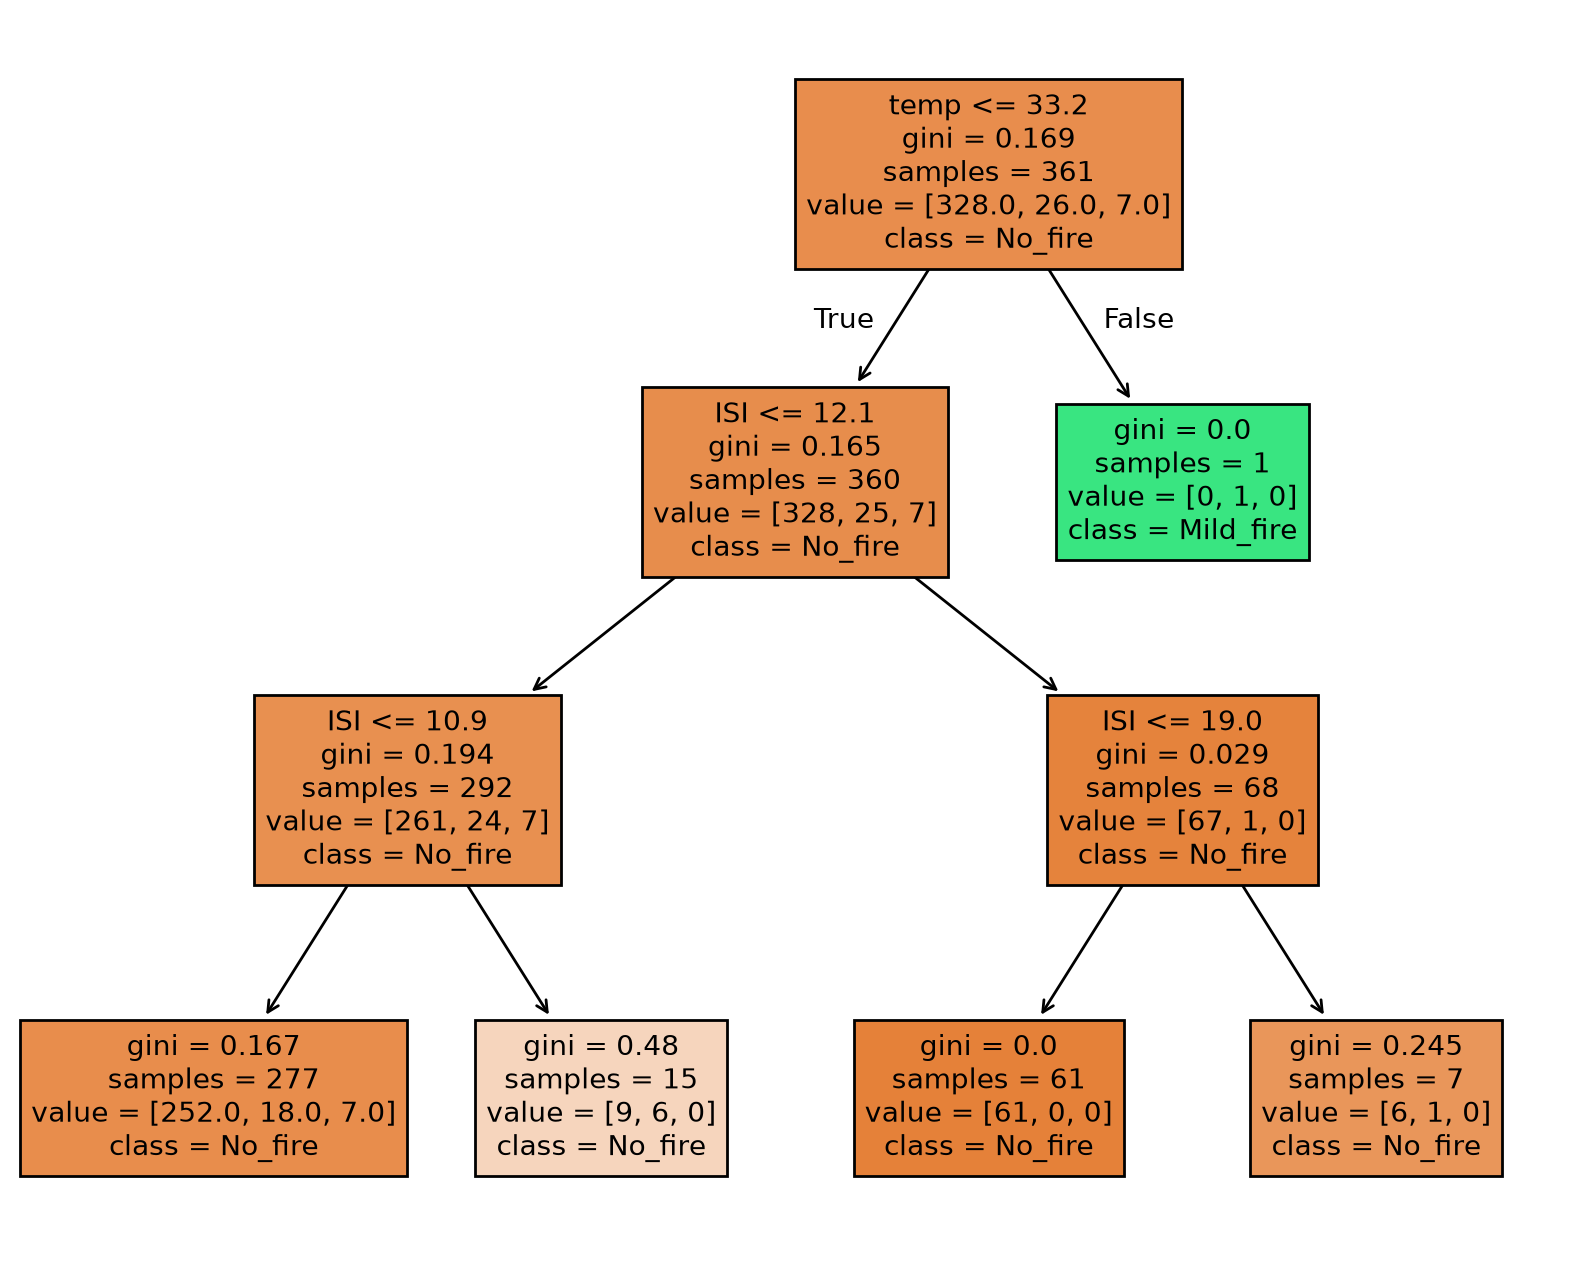

In [33]:
plt.figure(figsize=(10, 8), dpi=200, facecolor='w', edgecolor='k')
plot_tree(model_gini, filled=True, class_names=['No_fire','Mild_fire','Extreme_fire'], feature_names=list(data.columns))
plt.show();


In [34]:
model_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3)
model_entropy.fit(x_train, y_train)
y_pred_entropy = model_entropy.predict(x_test)

print('\nTest Results (entropy)')
print('Accuracy: {}'.format(model_entropy.score(x_test, y_test)))
print(confusion_matrix(y_test, y_pred_entropy))


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample


Test Results (entropy)
Accuracy: 0.8589743589743589
[[134   6   0]
 [ 14   0   0]
 [  1   1   0]]


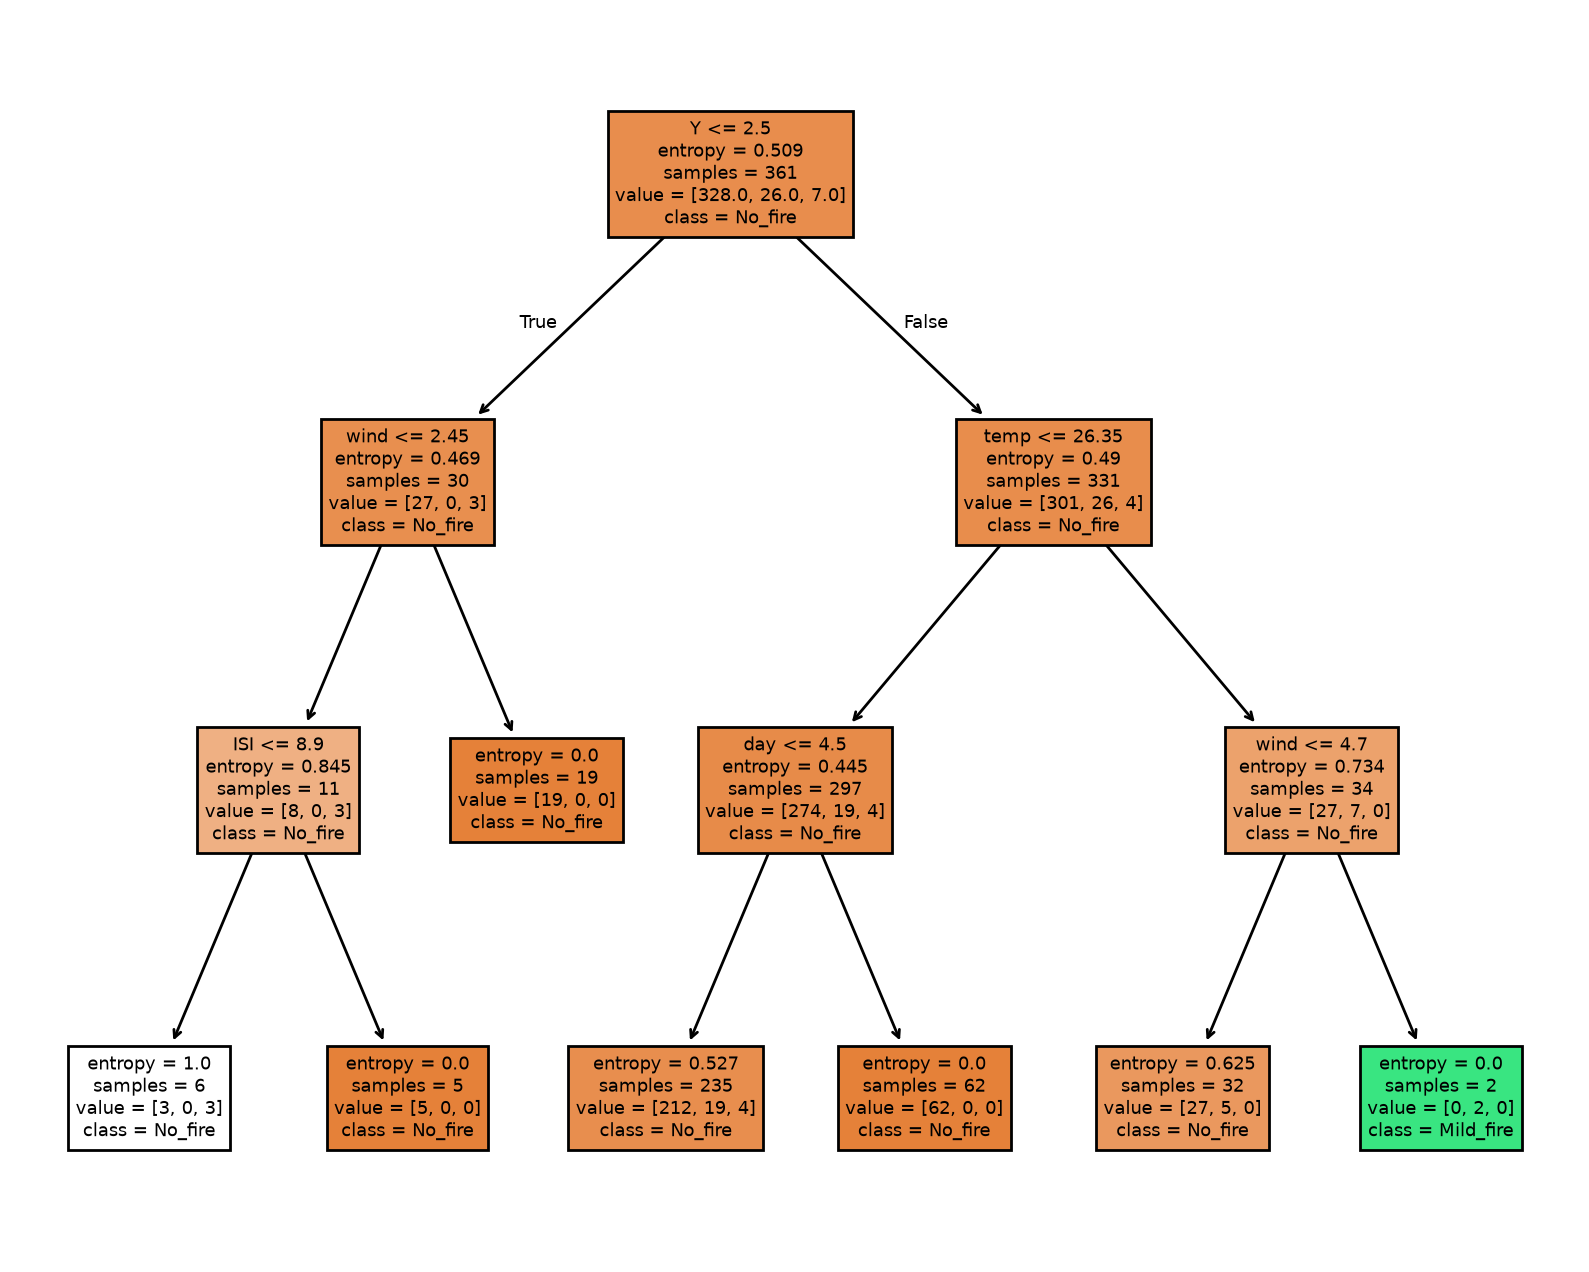

In [35]:
plt.figure(figsize=(10, 8), dpi=200, facecolor='w', edgecolor='k')
plot_tree(model_entropy, filled=True, class_names=['No_fire','Mild_fire','Extreme_fire'], feature_names=list(data.columns))
plt.show();


### Discussion of decision tree results 

The gini decision tree predicts almost every test sample as the No_fire class, which is why nearly all of the predictions appear in the first column of the confusion matrix. This results in a high accuracy of about 90% because most of the data belongs to the No_fire class. However, the model performs very poorly on the Mild_fire and Extreme_fire classes since it rarely predicts them correctly. This shows that accuracy alone can be misleading when the dataset is highly imbalanced.

## KNN
Import libraries for KNN


In [36]:
# KNN
# FIX (documented): removed dead imports (sklearn.externals.six, pydotplus,
# export_graphviz, mpimg, mpatches). They were unused and six no longer exists in sklearn.
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split


In [37]:
# Make a copy of original data frame and investigate the data types
knn_df = forest.copy()
knn_df.dtypes


X          int64
Y          int64
month        str
day          str
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object

In [38]:
# Transform object data types to categorical
categorical_cols = knn_df.select_dtypes('object').columns
knn_df[categorical_cols] = knn_df[categorical_cols].astype('category')
knn_df.dtypes
knn_df.head()


C:\Users\syeda\AppData\Local\Temp\ipykernel_22796\2415042126.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = knn_df.select_dtypes('object').columns


X           int64
Y           int64
month    category
day      category
FFMC      float64
DMC       float64
DC        float64
ISI       float64
temp      float64
RH          int64
wind      float64
rain      float64
area      float64
dtype: object

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


To obtain accurate nearest neighbor distance between days and months, we convert 'months' and 'days' to a circular format so the distance between Jan and Feb equals the distance between Dec and Jan. The same applies to days.


In [39]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
months = [item.lower() for item in months]

days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
days = [item.lower() for item in days]


Using a Fourier-style mapping on the unit circle, we map 'day' and 'month' to complex data


In [40]:
months_complex = np.exp(-1j*2*np.pi* np.arange(1,13) /12)
days_complex   = np.exp(-1j*2*np.pi* np.arange(1,8) /7)


In [41]:
# Map each day/month to its corresponding complex value
knn_df['months_comp'] = [ months_complex[months.index(item)] for item in knn_df['month'] ]
knn_df['days_comp']   = [ days_complex[days.index(item)] for item in knn_df['day'] ]

# Convert area to discrete bins (same bins as the decision tree section)
knn_df['area'] = pd.cut(knn_df['area'], include_lowest=True, bins=bins, labels=labels)


In [42]:
# FIX (documented): the original code trained KNN on `df`, throwing away the circular
# month/day encoding built above in `knn_df`. KNN also cannot compute distances on complex
# numbers, so we split each complex column into real and imaginary parts and train on knn_df.

knn_df['month_cos'] = knn_df['months_comp'].apply(lambda z: z.real)
knn_df['month_sin'] = knn_df['months_comp'].apply(lambda z: z.imag)
knn_df['day_cos']   = knn_df['days_comp'].apply(lambda z: z.real)
knn_df['day_sin']   = knn_df['days_comp'].apply(lambda z: z.imag)

target = knn_df['area']
data = knn_df.drop(['month', 'day', 'area', 'months_comp', 'days_comp'], axis=1)

x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=.3, random_state=1)
k_values = list(range(3, 30, 3))
model = [ KNeighborsClassifier(n_neighbors=k) for k in k_values ]
[ model[idx].fit(x_train, y_train) for idx in range(len(model)) ]


[KNeighborsClassifier(n_neighbors=3),
 KNeighborsClassifier(n_neighbors=6),
 KNeighborsClassifier(n_neighbors=9),
 KNeighborsClassifier(n_neighbors=12),
 KNeighborsClassifier(n_neighbors=15),
 KNeighborsClassifier(n_neighbors=18),
 KNeighborsClassifier(n_neighbors=21),
 KNeighborsClassifier(n_neighbors=24),
 KNeighborsClassifier(n_neighbors=27)]

In [43]:
print('\nTest Results')
[ print('Training Accuracy for k = {} is {} '.format(k_values[k], model[k].score(x_train, y_train))) for k in range(len(model)) ]
[ print('Test Accuracy for k = {} is {} '.format(k_values[k], model[k].score(x_test, y_test))) for k in range(len(model)) ]



Test Results
Training Accuracy for k = 3 is 0.925207756232687 
Training Accuracy for k = 6 is 0.9085872576177285 
Training Accuracy for k = 9 is 0.9085872576177285 
Training Accuracy for k = 12 is 0.9085872576177285 
Training Accuracy for k = 15 is 0.9085872576177285 
Training Accuracy for k = 18 is 0.9085872576177285 
Training Accuracy for k = 21 is 0.9085872576177285 
Training Accuracy for k = 24 is 0.9085872576177285 
Training Accuracy for k = 27 is 0.9085872576177285 


[None, None, None, None, None, None, None, None, None]

Test Accuracy for k = 3 is 0.8653846153846154 
Test Accuracy for k = 6 is 0.8974358974358975 
Test Accuracy for k = 9 is 0.8974358974358975 
Test Accuracy for k = 12 is 0.8974358974358975 
Test Accuracy for k = 15 is 0.8974358974358975 
Test Accuracy for k = 18 is 0.8974358974358975 
Test Accuracy for k = 21 is 0.8974358974358975 
Test Accuracy for k = 24 is 0.8974358974358975 
Test Accuracy for k = 27 is 0.8974358974358975 


[None, None, None, None, None, None, None, None, None]

### KNN result discussion 

The KNN model achieves almost the same test accuracy as the decision tree, especially for k values of 6 and higher. Similar to the decision tree, it mostly predicts the majority No_fire class, so the overall accuracy stays high. Increasing k beyond 6 does not improve the results because the predictions become stable and the majority class continues to dominate. Even though the month and day features were encoded better, the class imbalance still has a much larger effect on the model's performance.


# Part 2: Balancing the Data

Copy of the decision tree analysis with `class_weight='balanced'` added. This tells the tree to weight the rare classes more heavily so it stops ignoring them.


In [44]:
# Rebuild the decision-tree data/target (in case the KNN section reassigned these names)
target_dt = df['area']
data_dt = df.drop(['area'], axis=1)
xtr_b, xte_b, ytr_b, yte_b = train_test_split(data_dt, target_dt, test_size=.3, random_state=1)

model_balanced = DecisionTreeClassifier(criterion='gini', max_depth=3, class_weight='balanced')
model_balanced.fit(xtr_b, ytr_b)
y_pred_balanced = model_balanced.predict(xte_b)

print('Balanced tree — Test Results')
print('Accuracy: {}'.format(model_balanced.score(xte_b, yte_b)))
print(confusion_matrix(yte_b, y_pred_balanced))


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But th

Balanced tree — Test Results
Accuracy: 0.17307692307692307
[[20 73 47]
 [ 2  6  6]
 [ 0  1  1]]


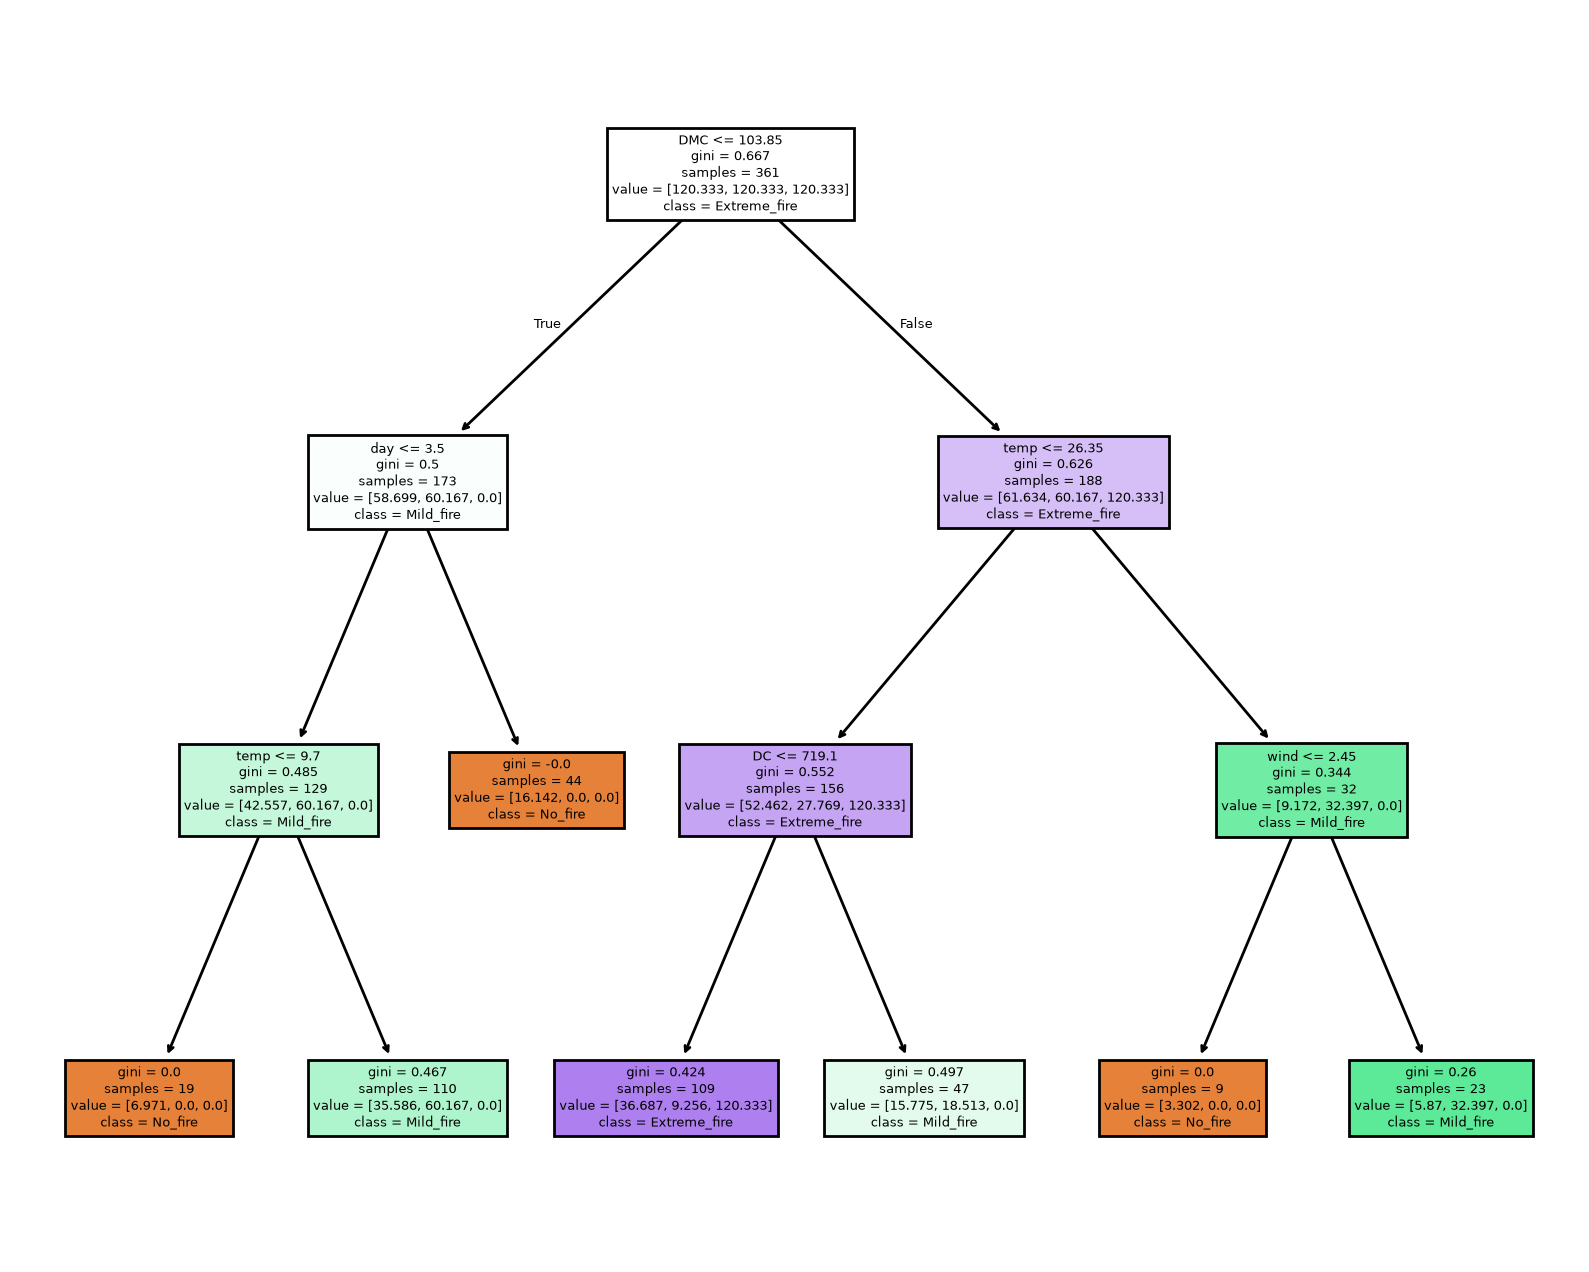

In [45]:
plt.figure(figsize=(10, 8), dpi=200, facecolor='w', edgecolor='k')
plot_tree(model_balanced, filled=True, class_names=['No_fire','Mild_fire','Extreme_fire'], feature_names=list(data_dt.columns))
plt.show();


### Part 2 discussion

Unlike the original decision tree, the balanced tree predicts all three classes much more often instead of almost always predicting No_fire. As a result, it correctly identifies more Mild_fire and Extreme_fire samples, but it also makes many more mistakes on the No_fire class. This causes the overall accuracy to drop significantly from about 90% to around 17%. The balanced model sacrifices overall accuracy in order to give minority classes a better chance of being predicted.

# Part 3: F1 Scores for All Classifiers

Accuracy is misleading on imbalanced data because always predicting the majority class scores high. The F1 score is the harmonic mean of precision and recall, so it punishes a model that ignores the minority classes. We use `average='macro'` so each class counts equally regardless of size.

Reference: `sklearn.metrics.f1_score(y_true, y_pred, average='macro')`.


In [46]:
from sklearn.metrics import f1_score, accuracy_score

results = []

# Decision trees and the balanced tree all use the DT split (xte_b, yte_b)
for name, mdl in [('DT gini', model_gini), ('DT entropy', model_entropy), ('DT balanced', model_balanced)]:
    p = mdl.predict(xte_b)
    results.append((name, accuracy_score(yte_b, p), f1_score(yte_b, p, average='macro')))

# KNN models use the KNN split, which currently lives in x_test / y_test
for k, mdl in zip(k_values, model):
    p = mdl.predict(x_test)
    results.append(('KNN k={}'.format(k), accuracy_score(y_test, p), f1_score(y_test, p, average='macro')))

print('{:<14} {:>10} {:>12}'.format('Model', 'Accuracy', 'F1 (macro)'))
for name, acc, f1 in results:
    print('{:<14} {:>10.4f} {:>12.4f}'.format(name, acc, f1))


Model            Accuracy   F1 (macro)
DT gini            0.8974       0.3153
DT entropy         0.8590       0.3091
DT balanced        0.1731       0.1368
KNN k=3            0.8654       0.3093
KNN k=6            0.8974       0.3153
KNN k=9            0.8974       0.3153
KNN k=12           0.8974       0.3153
KNN k=15           0.8974       0.3153
KNN k=18           0.8974       0.3153
KNN k=21           0.8974       0.3153
KNN k=24           0.8974       0.3153
KNN k=27           0.8974       0.3153


### Part 3 discussion 
The large difference between accuracy and macro F1 score shows that the models are mainly succeeding because they predict the majority class correctly, while performing poorly on the minority classes. Although the decision tree and KNN models have accuracies close to 90%, their macro F1 scores are only around 0.31, indicating that the predictions are not balanced across all classes. The balanced decision tree has a lower accuracy and F1 score, but it attempts to classify every class instead of ignoring the smaller ones. Overall, the regular decision tree and KNN perform similarly, while the balanced tree provides more balanced predictions even though its overall performance is lower.

# Extra Credit: Decision Tree on the Titanic Data

Place `titanic.csv` (the Kaggle training file, the one with the `Survived` column) in the same folder as this notebook. The cell below loads it, does minimal cleaning, fits a decision tree, and reports accuracy, F1, the confusion matrix, and feature importances.


In [47]:
titanic = pd.read_csv('titanic.csv')

# Minimal cleaning
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1})
titanic['Embarked'] = titanic['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Xt = titanic[features]
yt = titanic['Survived']

xtr_t, xte_t, ytr_t, yte_t = train_test_split(Xt, yt, test_size=.3, random_state=1)
titanic_tree = DecisionTreeClassifier(max_depth=3, random_state=1)
titanic_tree.fit(xtr_t, ytr_t)
yp_t = titanic_tree.predict(xte_t)

print('Titanic decision tree')
print('Accuracy:  {:.4f}'.format(accuracy_score(yte_t, yp_t)))
print('F1 (macro):{:.4f}'.format(f1_score(yte_t, yp_t, average='macro')))
print(confusion_matrix(yte_t, yp_t))
print('Feature importances:', dict(zip(features, np.round(titanic_tree.feature_importances_, 3))))


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

Titanic decision tree
Accuracy:  0.7724
F1 (macro):0.7530
[[141  12]
 [ 49  66]]
Feature importances: {'Pclass': np.float64(0.189), 'Sex': np.float64(0.612), 'Age': np.float64(0.085), 'SibSp': np.float64(0.064), 'Parch': np.float64(0.0), 'Fare': np.float64(0.0), 'Embarked': np.float64(0.05)}


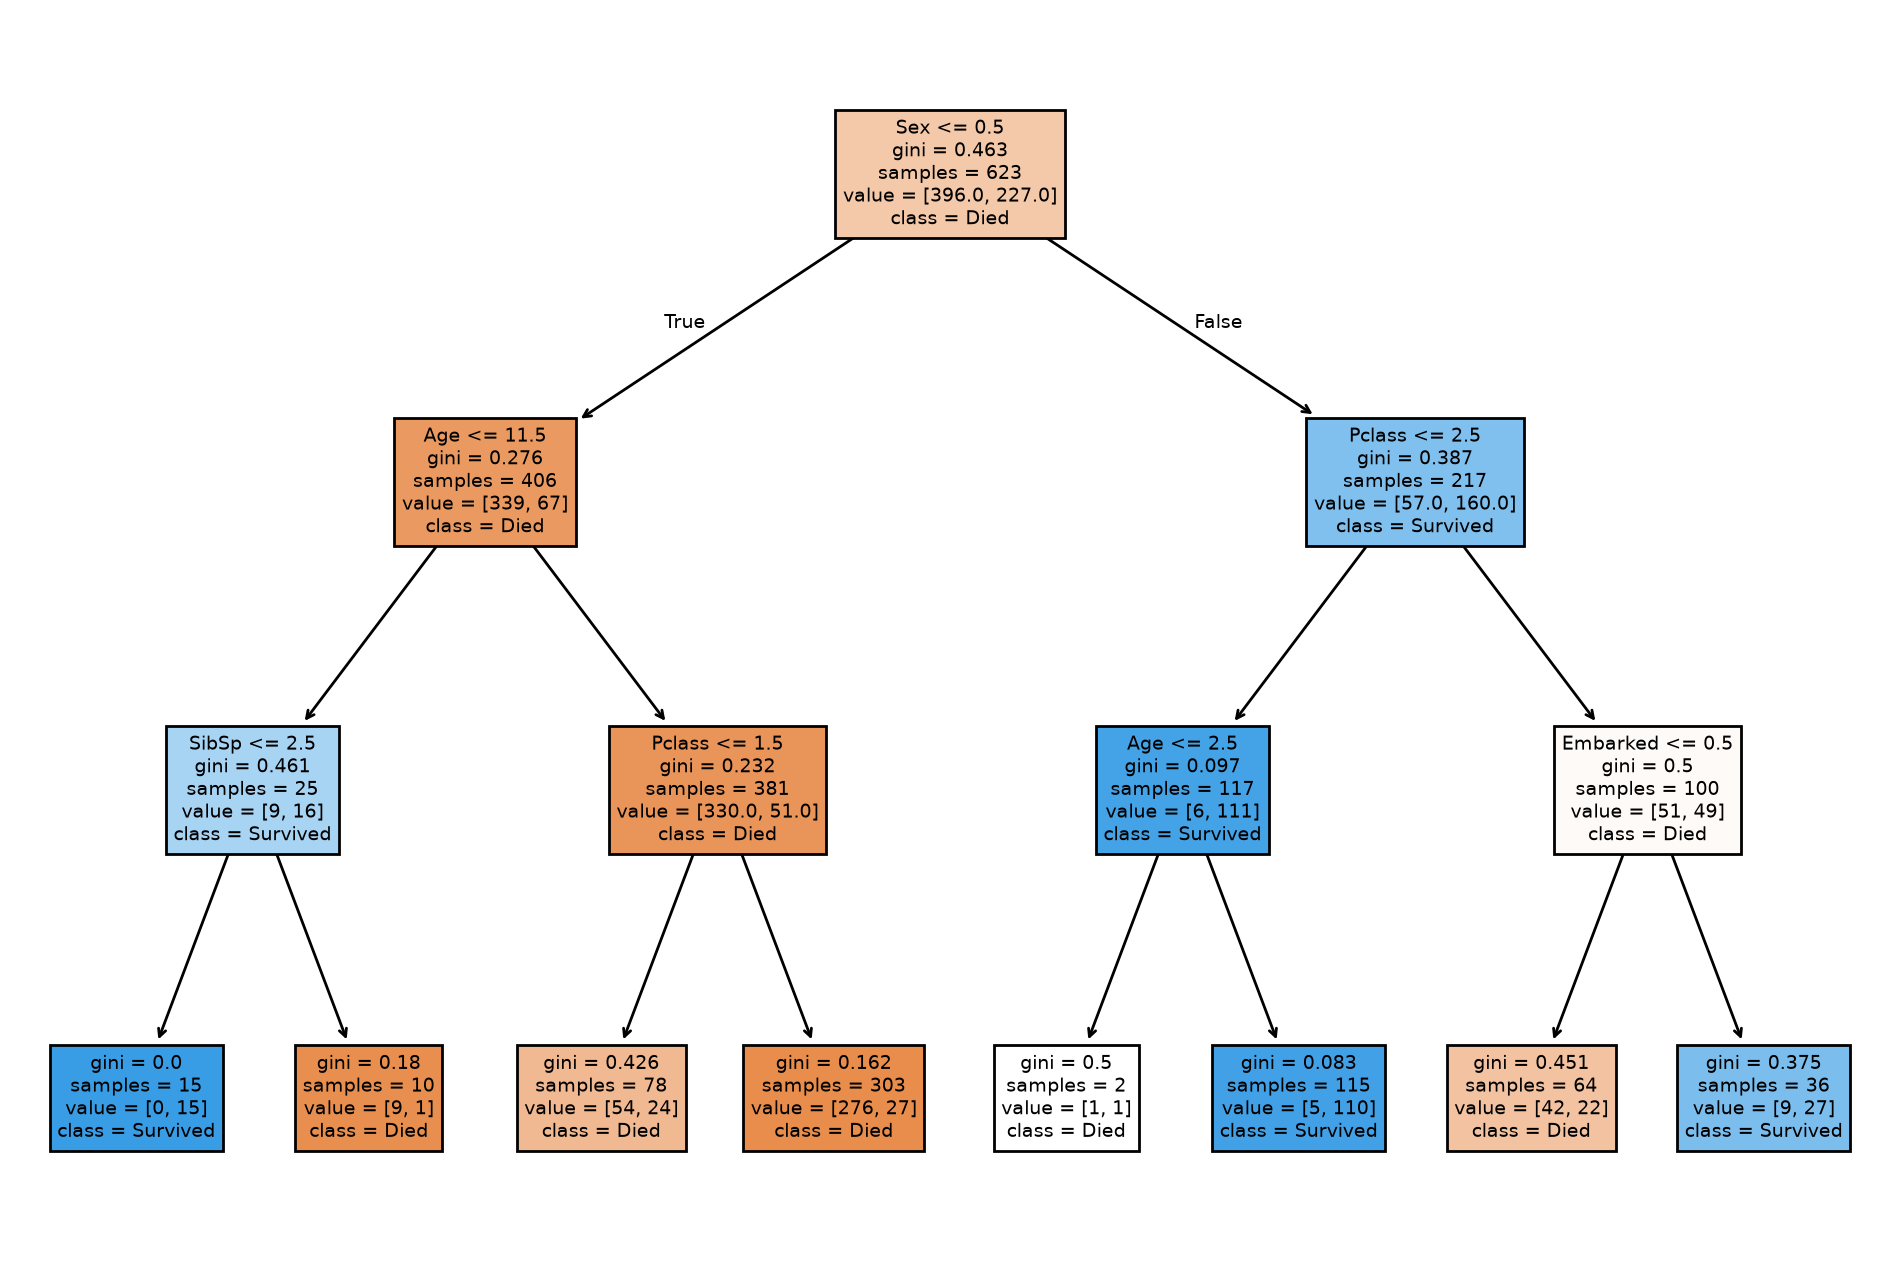

In [48]:
plt.figure(figsize=(12, 8), dpi=200, facecolor='w', edgecolor='k')
plot_tree(titanic_tree, filled=True, class_names=['Died','Survived'], feature_names=features)
plt.show();


### Extra credit discussion 

The most important feature is Sex, with an importance of about 0.61, which matches the historical idea of "women and children first" during the Titanic evacuation. Passenger class and age also contribute to the model, but they are much less important than sex. Unlike the forest fire dataset, the Titanic model has an F1 score that is much closer to its accuracy because the model performs reasonably well on both classes instead of focusing almost entirely on one class. This indicates that the Titanic dataset is much less affected by class imbalance and provides a more balanced evaluation of the model.
